# Stat 153/248 - Lecture 19

Here we will extend the concepts from Lecture 18 to ARIMA.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import signal
import warnings
warnings.filterwarnings('ignore')

# statsmodels imports
from statsmodels.tsa.stattools import acf, pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox


import warnings
from statsmodels.tools.sm_exceptions import ConvergenceWarning
warnings.filterwarnings('ignore', category=ConvergenceWarning)

plt.rcParams.update({
    'figure.figsize': (12, 4),
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 16,
})

## The ARIMA model and GDP

Here we'll use [data from FRED](https://fred.stlouisfed.org/series/GDPC1) (Federal Reserve Economic Data) on the GDP.

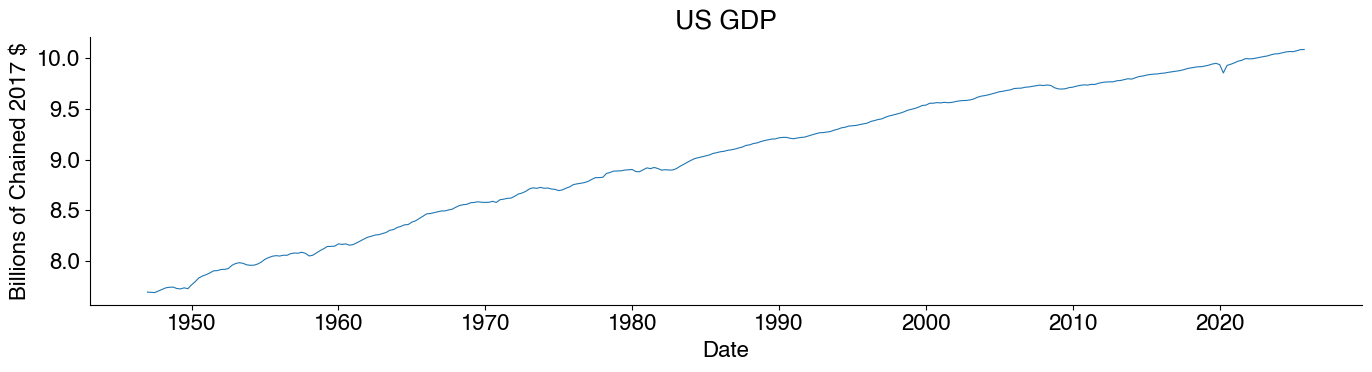

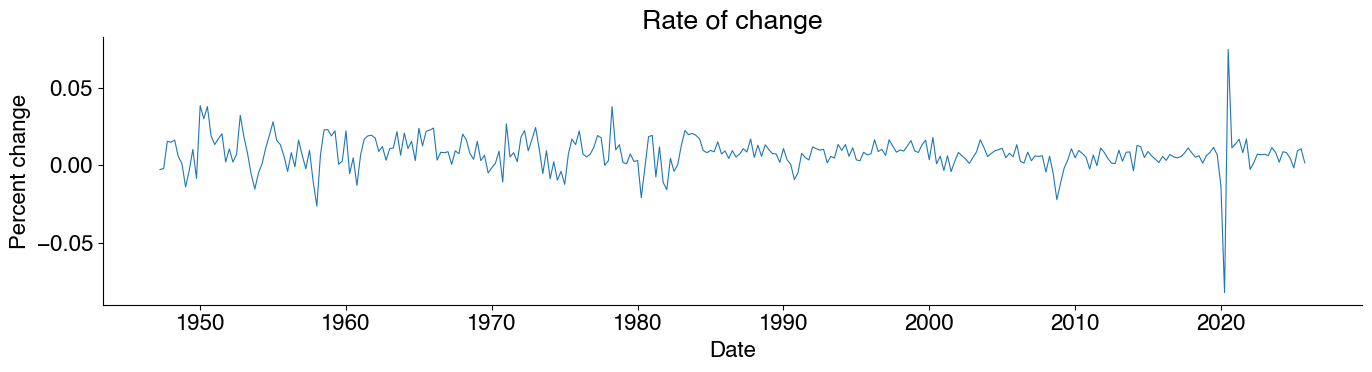

Series length: 316 observations
Mean: 9.02, Std: 0.70


In [4]:
# US GDP (seasonally adjusted)
# Source: FRED series GDPC1

gdp = pd.read_csv('GDPC1.csv', parse_dates=['observation_date'], index_col='observation_date').dropna()
y_gdp = np.log(gdp['GDPC1'].values)
log_change = np.diff(y_gdp)

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(gdp.index, y_gdp, linewidth=0.8)
ax.set(xlabel='Date', ylabel='Billions of Chained 2017 $', 
       title='US GDP')
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(gdp.index[1:], log_change, linewidth=0.8)
ax.set(xlabel='Date', ylabel='Percent change', 
       title='Rate of change')
plt.tight_layout()
plt.show()

print(f"Series length: {len(y_gdp)} observations")
print(f"Mean: {np.mean(y_gdp):.2f}, Std: {np.std(y_gdp):.2f}")


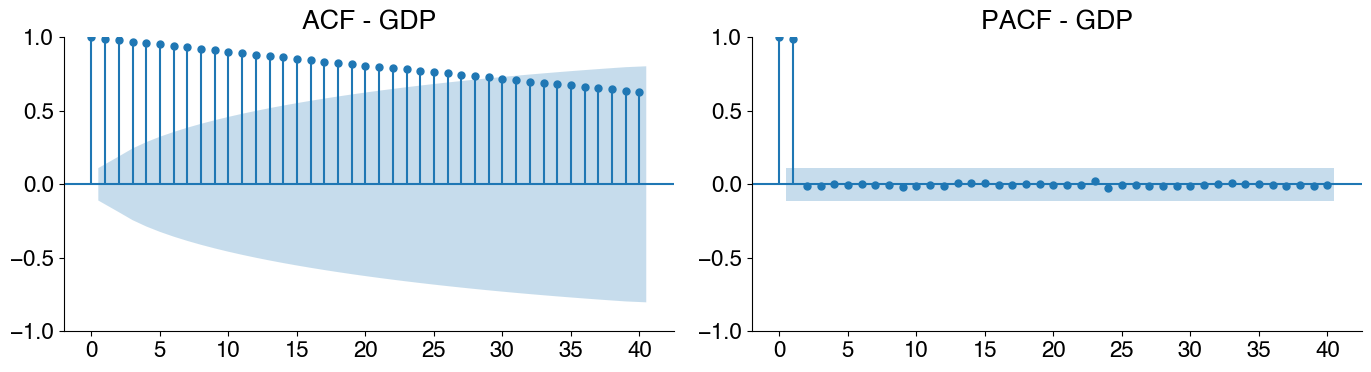

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

plot_acf(y_gdp, lags=40, ax=axes[0], title='ACF - GDP')
plot_pacf(y_gdp, lags=40, ax=axes[1], title='PACF - GDP', method='ywm')

plt.tight_layout()
plt.show()

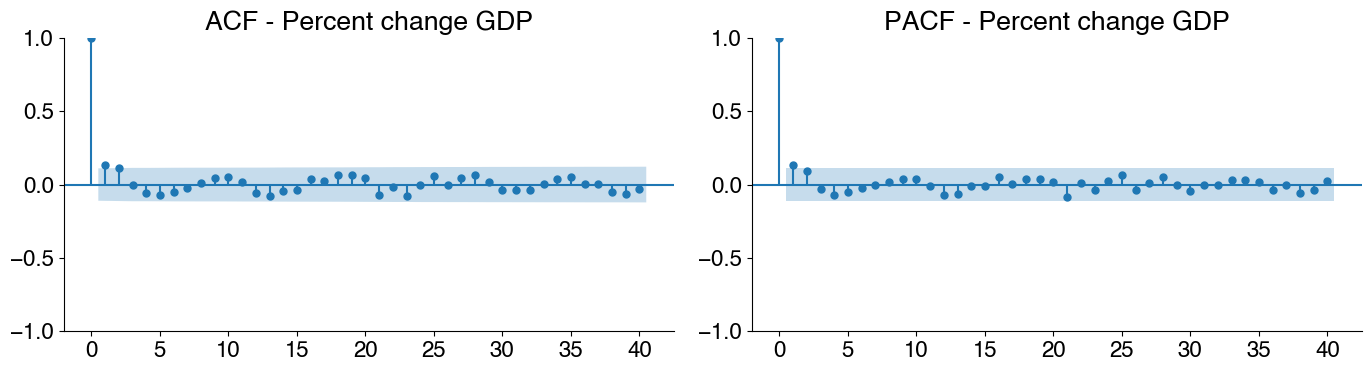

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(log_change, lags=40, ax=axes[0], title='ACF - Percent change GDP')
plot_pacf(log_change, lags=40, ax=axes[1], title='PACF - Percent change GDP', method='ywm')

plt.tight_layout()
plt.show()

# Fitting the model

First we will fit up until the last 20 quarters (5 years) of data and forecast to the latest 5, using several different models that incorporate AR(), MA(), and differencing terms, and comparing them

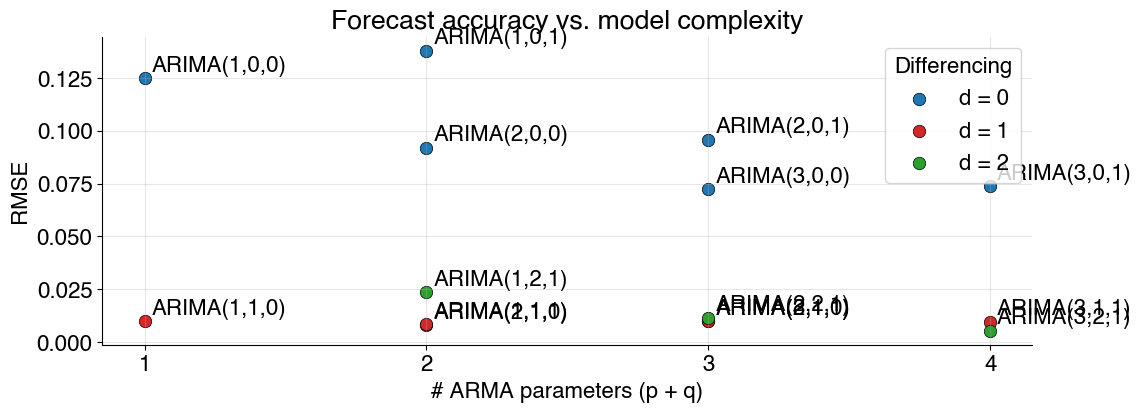

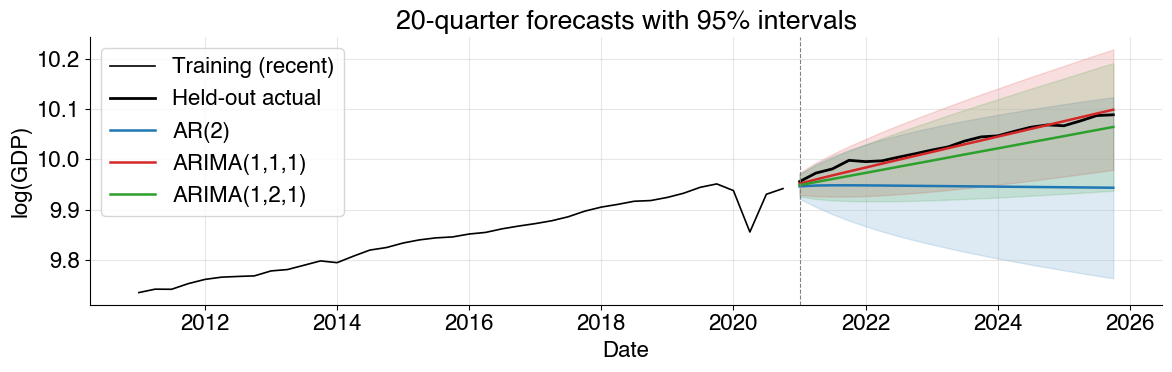

In [27]:
# ---- 2. Train/test split ----
h = 20 # 5 years of data

y_train = y_gdp[:-h] # take up to the last five years
y_test = y_gdp[-h:]  # predict last five years
dates_train = gdp.index[:-h]
dates_test = gdp.index[-h:]

# ---- 3. Model grid ----
specs = [
    (1, 0, 0), (2, 0, 0), (3, 0, 0), # p, d, q - AR models
    (1, 0, 1), (2, 0, 1), (3, 0, 1), # ARMA models
    (1, 1, 0), (2, 1, 0), (3, 1, 0), # ARI (differencing, no MA)
    (1, 1, 1), (2, 1, 1), (3, 1, 1), # ARIMA d=1
    (1, 2, 1), (2, 2, 1), (3, 2, 1), # ARIMA d=2
]

# ---- 4. Fit, forecast, score ----
results = []
fits = {}
for (p, d, q) in specs:
    try:
        if d == 0:
            trend = 'c'
        elif d == 1:
            trend = 't'   # was 'n'
        else:
            trend = 'n'
        fit = ARIMA(y_train, order=(p, d, q), trend=trend).fit()
        fcast = fit.get_forecast(steps=h)
        mean = np.asarray(fcast.predicted_mean)
        ci = np.asarray(fcast.conf_int(alpha=0.05))
        rmse = np.sqrt(np.mean((mean - y_test) ** 2))
        results.append({
            'spec': f'ARIMA({p},{d},{q})',
            'p': p, 'd': d, 'q': q,
            'n_params': p + q,
            'rmse': rmse,
        })
        fits[(p, d, q)] = (mean, ci)
    except Exception as e:
        print(f'ARIMA({p},{d},{q}) failed: {e}')

df = pd.DataFrame(results)

plt.figure()

# RMSE vs. complexity
colors = {0: 'C0', 1: 'C3', 2: 'C2'}

for d_val in sorted(df['d'].unique()):
    sub = df[df['d'] == d_val]
    plt.scatter(sub['n_params'], sub['rmse'],
               c=colors[d_val], s=80,
               label=f'd = {d_val}', edgecolor='k', linewidth=0.5)
    for _, row in sub.iterrows():
        plt.gca().annotate(row['spec'], (row['n_params'], row['rmse']),
                    xytext=(5, 5), textcoords='offset points')

plt.xlabel('# ARMA parameters (p + q)')
plt.gca().set_xticks(np.arange(1,5))
plt.ylabel(f'RMSE')
plt.title('Forecast accuracy vs. model complexity')
plt.legend(title='Differencing', loc='upper right')
plt.grid(alpha=0.3)

# Forecast


plt.figure()
context = 40 # Quarters to look back in the past (zooming in)
plt.plot(dates_train[-context:], y_train[-context:],
        color='black', lw=1.2, label='Training (recent)')
plt.plot(dates_test, y_test, color='black', lw=2, label='Held-out actual')

highlight = {
    (2, 0, 0): ('AR(2)', 'C0'),
    (1, 1, 1): ('ARIMA(1,1,1)', 'C3'),
    (1, 2, 1): ('ARIMA(1,2,1)', 'C2'),
}

for spec, (label, color) in highlight.items():
    if spec not in fits:
        continue
    mean, ci = fits[spec]
    plt.plot(dates_test, mean, color=color, lw=1.8, label=label)
    plt.fill_between(dates_test, ci[:, 0], ci[:, 1], color=color, alpha=0.15)

plt.axvline(dates_test[0], color='gray', ls='--', lw=0.8)
plt.xlabel('Date')
plt.ylabel('log(GDP)')
plt.title(f'{h}-quarter forecasts with 95% intervals')
plt.legend(loc='upper left')
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Changes in linear trends

Here our data includes the COVID-19 pandemic years in the training set, where there were strong changes to the linear trend in GDP that can't be captured by first order differencing. What if we restrict our time points to pre-COVID?

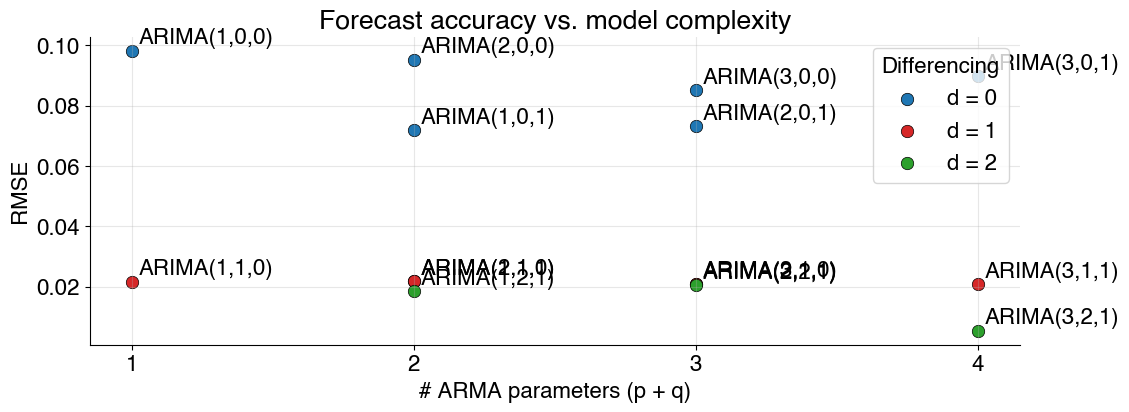

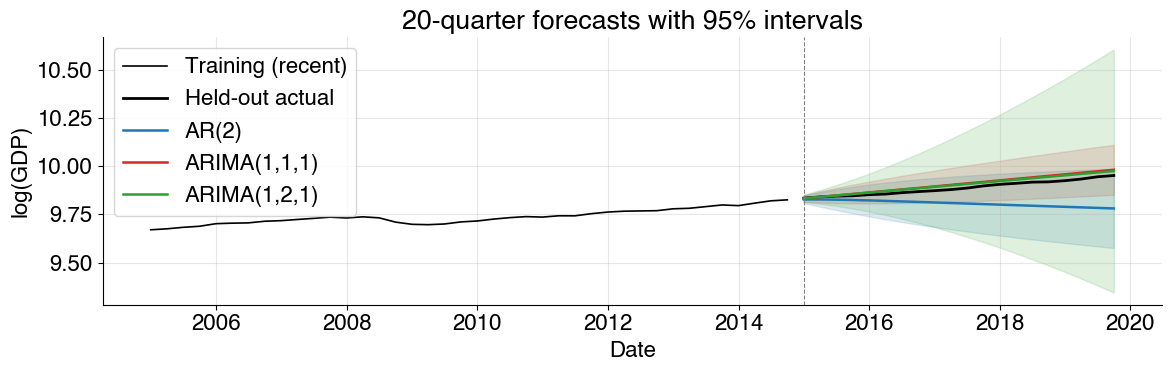

In [8]:
# ---- 2. Train/test split ----
# Truncate to pre-COVID
mask = gdp.index <= '2019-12-31'
y_pre = y_gdp[mask]
dates_pre = gdp.index[mask]

h = 20
y_train = y_pre[:-h]
y_test = y_pre[-h:]
dates_train = dates_pre[:-h]
dates_test = dates_pre[-h:]

# ---- 3. Model grid ----
specs = [
    (1, 0, 0), (2, 0, 0), (3, 0, 0),
    (1, 0, 1), (2, 0, 1), (3, 0, 1),
    (1, 1, 0), (2, 1, 0), (3, 1, 0),
    (1, 1, 1), (2, 1, 1), (3, 1, 1),
    (1, 2, 1), (2, 2, 1), (3, 2, 1),
]

# ---- 4. Fit, forecast, score ----
results = []
fits = {}
for (p, d, q) in specs:
    try:
        if d == 0:
            trend = 'c'
        elif d == 1:
            trend = 't'   # was 'n'
        else:
            trend = 'n'
        fit = ARIMA(y_train, order=(p, d, q), trend=trend).fit()
        fcast = fit.get_forecast(steps=h)
        mean = np.asarray(fcast.predicted_mean)
        ci = np.asarray(fcast.conf_int(alpha=0.05))
        rmse = np.sqrt(np.mean((mean - y_test) ** 2))
        results.append({
            'spec': f'ARIMA({p},{d},{q})',
            'p': p, 'd': d, 'q': q,
            'n_params': p + q,
            'rmse': rmse,
        })
        fits[(p, d, q)] = (mean, ci)
    except Exception as e:
        print(f'ARIMA({p},{d},{q}) failed: {e}')

df = pd.DataFrame(results)

plt.figure()

# RMSE vs. complexity
colors = {0: 'C0', 1: 'C3', 2: 'C2'}

for d_val in sorted(df['d'].unique()):
    sub = df[df['d'] == d_val]
    plt.scatter(sub['n_params'], sub['rmse'],
               c=colors[d_val], s=80,
               label=f'd = {d_val}', edgecolor='k', linewidth=0.5)
    for _, row in sub.iterrows():
        plt.gca().annotate(row['spec'], (row['n_params'], row['rmse']),
                    xytext=(5, 5), textcoords='offset points')

plt.xlabel('# ARMA parameters (p + q)')
plt.gca().set_xticks(np.arange(1,5))
plt.ylabel(f'RMSE')
plt.title('Forecast accuracy vs. model complexity')
plt.legend(title='Differencing', loc='upper right')
plt.grid(alpha=0.3)

# Forecast


plt.figure()
context = 40 # Quarters to look back in the past (zooming in)
plt.plot(dates_train[-context:], y_train[-context:],
        color='black', lw=1.2, label='Training (recent)')
plt.plot(dates_test, y_test, color='black', lw=2, label='Held-out actual')

highlight = {
    (2, 0, 0): ('AR(2)', 'C0'),
    (1, 1, 1): ('ARIMA(1,1,1)', 'C3'),
    (1, 2, 1): ('ARIMA(1,2,1)', 'C2'),
}

for spec, (label, color) in highlight.items():
    if spec not in fits:
        continue
    mean, ci = fits[spec]
    plt.plot(dates_test, mean, color=color, lw=1.8, label=label)
    plt.fill_between(dates_test, ci[:, 0], ci[:, 1], color=color, alpha=0.15)

plt.axvline(dates_test[0], color='gray', ls='--', lw=0.8)
plt.xlabel('Date')
plt.ylabel('log(GDP)')
plt.title(f'{h}-quarter forecasts with 95% intervals')
plt.legend(loc='upper left')
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## More problems...

Here we see a little less advantage from the $d=2$ model, but it's possible that economic shifts related to the 2008 financial crisis are at play here.. so what if we go even further back, to when the linear trend in GDP was more stable? (pre-2008)?

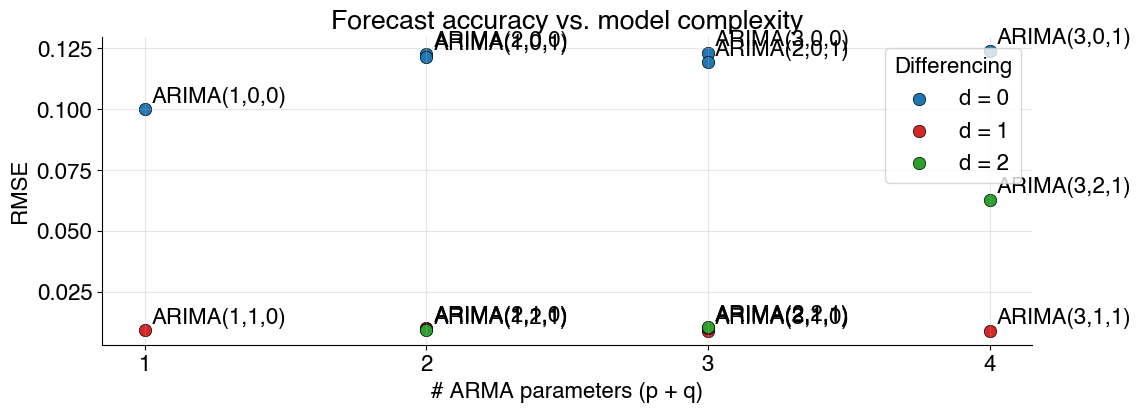

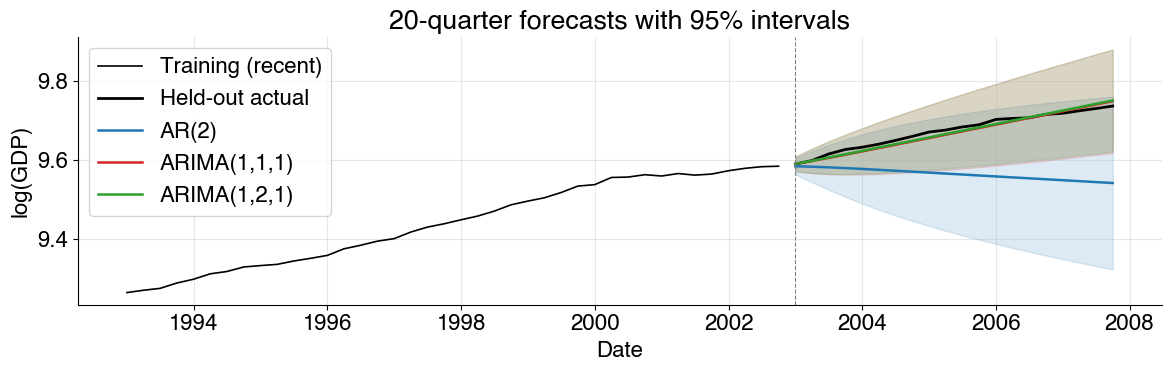

In [9]:
# ---- 2. Train/test split ----
mask = gdp.index <= '2007-12-31'
y_pre = y_gdp[mask]
dates_pre = gdp.index[mask]

h = 20
y_train = y_pre[:-h]
y_test = y_pre[-h:]
dates_train = dates_pre[:-h]
dates_test = dates_pre[-h:]

# ---- 3. Model grid ----
specs = [
    (1, 0, 0), (2, 0, 0), (3, 0, 0),
    (1, 0, 1), (2, 0, 1), (3, 0, 1),
    (1, 1, 0), (2, 1, 0), (3, 1, 0),
    (1, 1, 1), (2, 1, 1), (3, 1, 1),
    (1, 2, 1), (2, 2, 1), (3, 2, 1),
]

# ---- 4. Fit, forecast, score ----
results = []
fits = {}
for (p, d, q) in specs:
    try:
        if d == 0:
            trend = 'c'
        elif d == 1:
            trend = 't'   # was 'n'
        else:
            trend = 'n'
        fit = ARIMA(y_train, order=(p, d, q), trend=trend).fit()
        fcast = fit.get_forecast(steps=h)
        mean = np.asarray(fcast.predicted_mean)
        ci = np.asarray(fcast.conf_int(alpha=0.05))
        rmse = np.sqrt(np.mean((mean - y_test) ** 2))
        results.append({
            'spec': f'ARIMA({p},{d},{q})',
            'p': p, 'd': d, 'q': q,
            'n_params': p + q,
            'rmse': rmse,
        })
        fits[(p, d, q)] = (mean, ci)
    except Exception as e:
        print(f'ARIMA({p},{d},{q}) failed: {e}')

df = pd.DataFrame(results)

plt.figure()

# RMSE vs. complexity
colors = {0: 'C0', 1: 'C3', 2: 'C2'}

for d_val in sorted(df['d'].unique()):
    sub = df[df['d'] == d_val]
    plt.scatter(sub['n_params'], sub['rmse'],
               c=colors[d_val], s=80,
               label=f'd = {d_val}', edgecolor='k', linewidth=0.5)
    for _, row in sub.iterrows():
        plt.gca().annotate(row['spec'], (row['n_params'], row['rmse']),
                    xytext=(5, 5), textcoords='offset points')

plt.xlabel('# ARMA parameters (p + q)')
plt.gca().set_xticks(np.arange(1,5))
plt.ylabel(f'RMSE')
plt.title('Forecast accuracy vs. model complexity')
plt.legend(title='Differencing', loc='upper right')
plt.grid(alpha=0.3)

# Forecast

plt.figure()
context = 40 # Quarters to look back in the past (zooming in)
plt.plot(dates_train[-context:], y_train[-context:],
        color='black', lw=1.2, label='Training (recent)')
plt.plot(dates_test, y_test, color='black', lw=2, label='Held-out actual')

highlight = {
    (2, 0, 0): ('AR(2)', 'C0'),
    (1, 1, 1): ('ARIMA(1,1,1)', 'C3'),
    (1, 2, 1): ('ARIMA(1,2,1)', 'C2'),
}

for spec, (label, color) in highlight.items():
    if spec not in fits:
        continue
    mean, ci = fits[spec]
    plt.plot(dates_test, mean, color=color, lw=1.8, label=label)
    plt.fill_between(dates_test, ci[:, 0], ci[:, 1], color=color, alpha=0.15)

plt.axvline(dates_test[0], color='gray', ls='--', lw=0.8)
plt.xlabel('Date')
plt.ylabel('log(GDP)')
plt.title(f'{h}-quarter forecasts with 95% intervals')
plt.legend(loc='upper left')
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# What does this mean?

So what does this mean about AR, ARMA, and ARIMA models and their use? In each case, it's very important to understand and plot the underlying data and to look for trends *before* fitting models. For time series data that have multiple underlying trends or more complex behavior, *state space* methods (which we will discuss later) may be more helpful. The steps for building any ARIMA models should be:

1. Plot the data
2. Possibly transform the data (log transform, differencing, etc)
3. Identify the dependence orders of the model (inspect ACF, PACF)
4. Parameter estimation
5. Diagnostics
6. Choosing a model

# One more example

Let's look at one more example from the Shumway and Stoffer book. This dataset gives the thickness of the yearly varves collected from one location in Massachusetts for 634 years (beginning 11,834 years ago!). Varves are sedimentary deposits of sand and silt that are deposited by melting glaciers during the spring melting seasons (see Example 2.8 of the Shumway-Stoffer book, 5th edition). These deposits can be used as proxies for paleoclimatic parameters, such as temperature, because, in a warm year, more sand and silt are deposited from the receding glacier. 

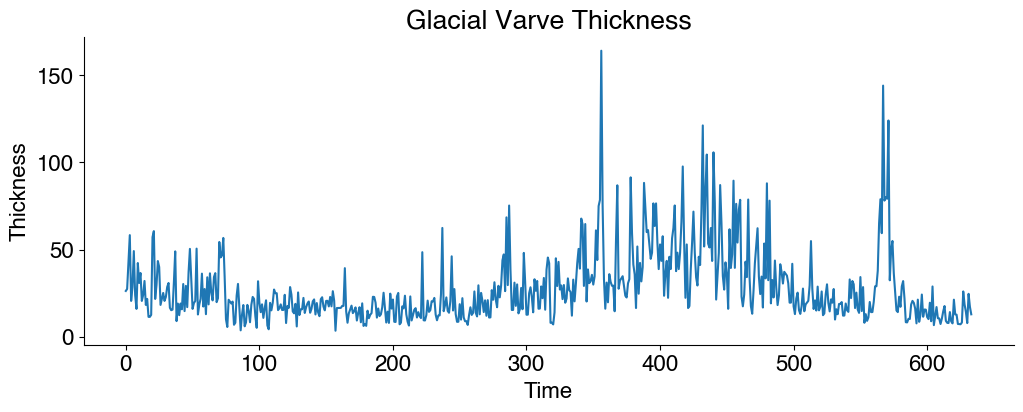

In [13]:
varve_data = pd.read_csv('varve.csv')

yraw = varve_data['x']
#plt.figure(figsize = (10, 8))
plt.plot(yraw)
plt.xlabel('Time')
plt.ylabel('Thickness')
plt.title('Glacial Varve Thickness')
plt.show()

## More plot diagnostics

From just looking at the plot, it appears that the variance may be nonstationary. We can also look at the QQ-plot, which shows us whether the data come from an underlying distribution (default: normal), and whether they violate the assumption of homoscedasticity. Here, we'll see that the QQ plot deviates significantly from the line, so we probably do need a variance stabilizing transform (like the logarithm).

<Figure size 1200x400 with 0 Axes>

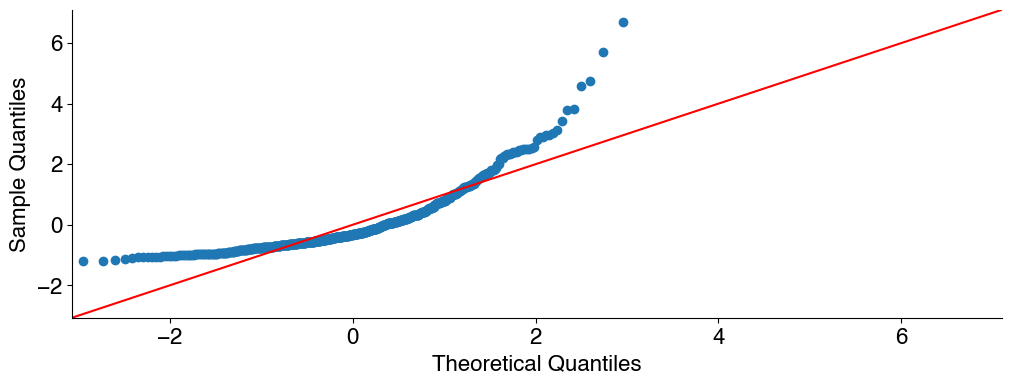

In [14]:
from statsmodels.graphics.gofplots import qqplot

plt.figure()
qqplot(yraw, fit=True, line="45");

If we log-transform the data, this will be better behaved.

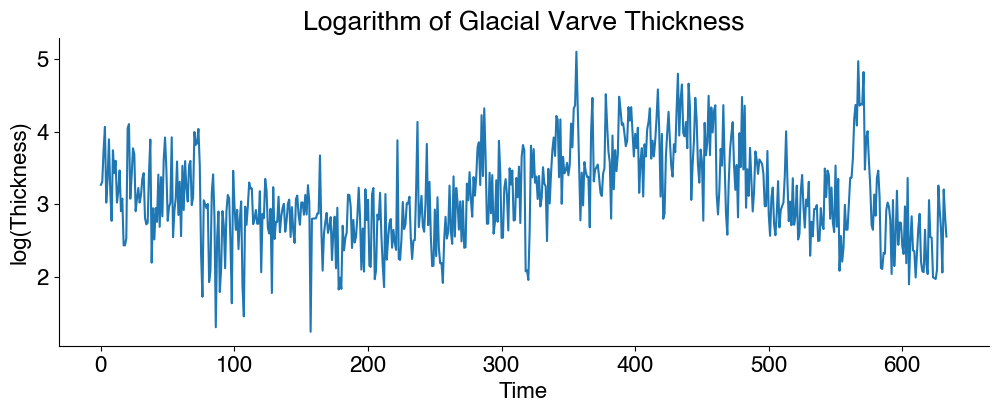

In [15]:
#Log transform the data first
ylog = np.log(yraw)
#plt.figure(figsize = (12, 6))
plt.plot(ylog)
plt.xlabel('Time')
plt.ylabel('log(Thickness)')
plt.title('Logarithm of Glacial Varve Thickness')
plt.show()

<Figure size 1200x400 with 0 Axes>

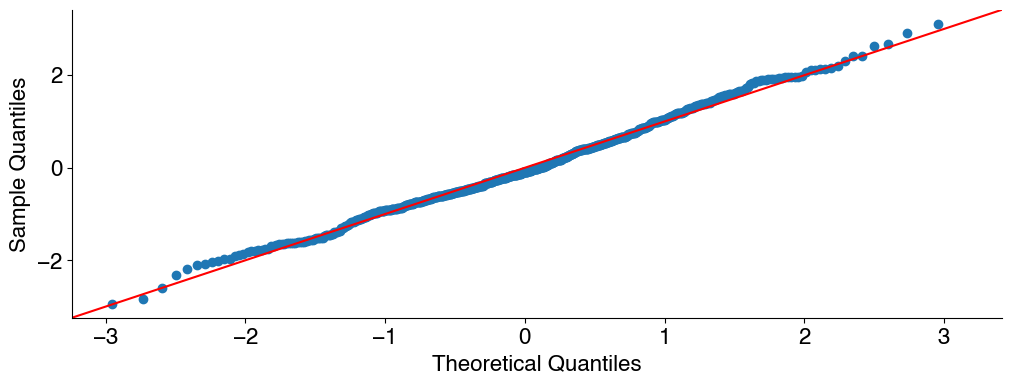

In [16]:
plt.figure()
qqplot(ylog, fit=True, line="45");

## ACF and PACF

In addition to the log transform, we're going to difference our data, then look at the ACF and PACF to see what to do next.

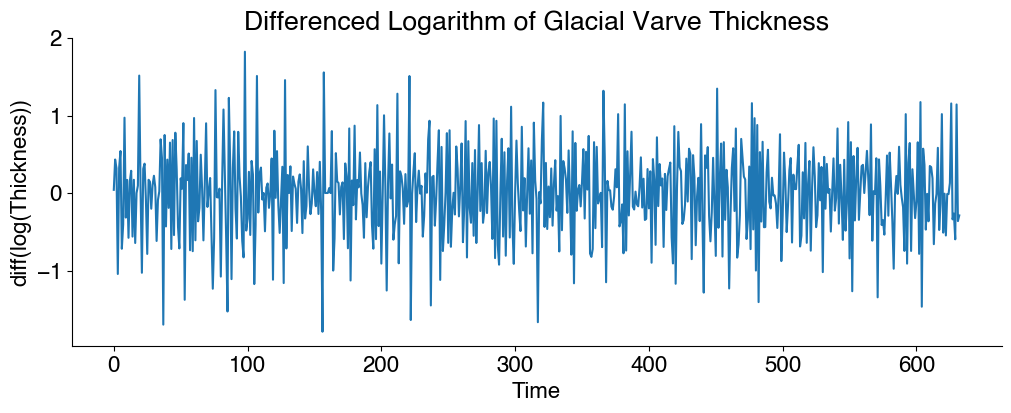

In [18]:
ylogdiff = np.diff(ylog)
#plt.figure(figsize = (12, 6))
plt.plot(ylogdiff)
plt.xlabel('Time')
plt.ylabel('diff(log(Thickness))')
plt.title('Differenced Logarithm of Glacial Varve Thickness')
plt.show()

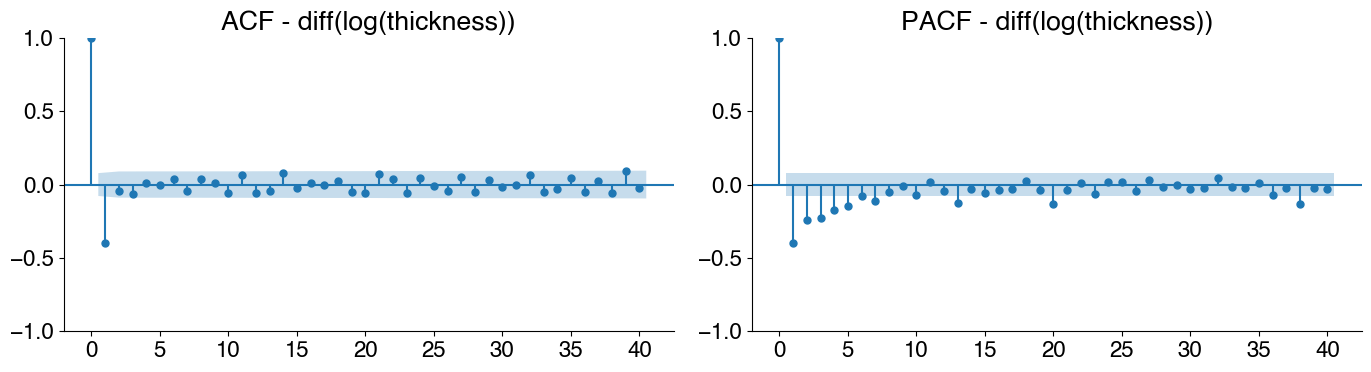

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

plot_acf(ylogdiff, lags=40, ax=axes[0], title='ACF - diff(log(thickness))')
plot_pacf(ylogdiff, lags=40, ax=axes[1], title='PACF - diff(log(thickness))', method='ywm')

plt.tight_layout()
plt.show()

Function |  AR(p)    | MA(q)                | ARMA(p,q)
---------|-----------|----------------------|----------
ACF      | tails off | cuts off after lag q | tails off
PACF     | cuts off after lag p | tails off | tails off

*What kind of model should we try?*

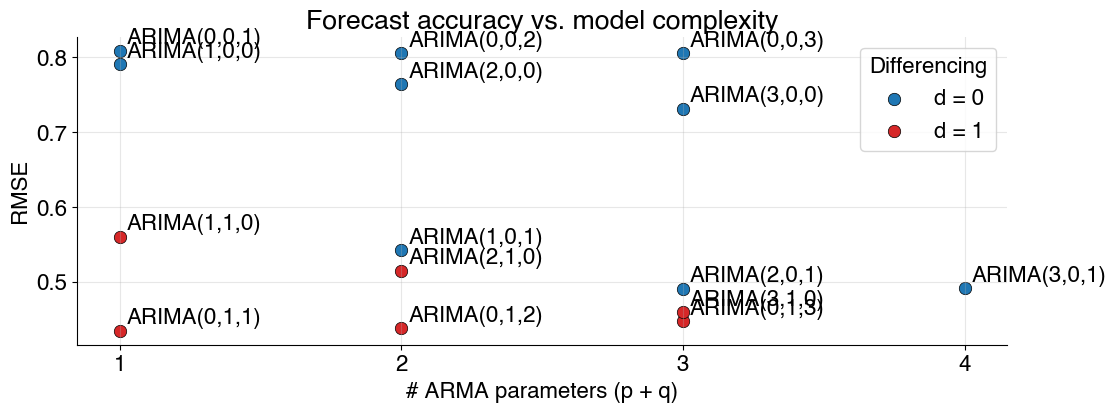

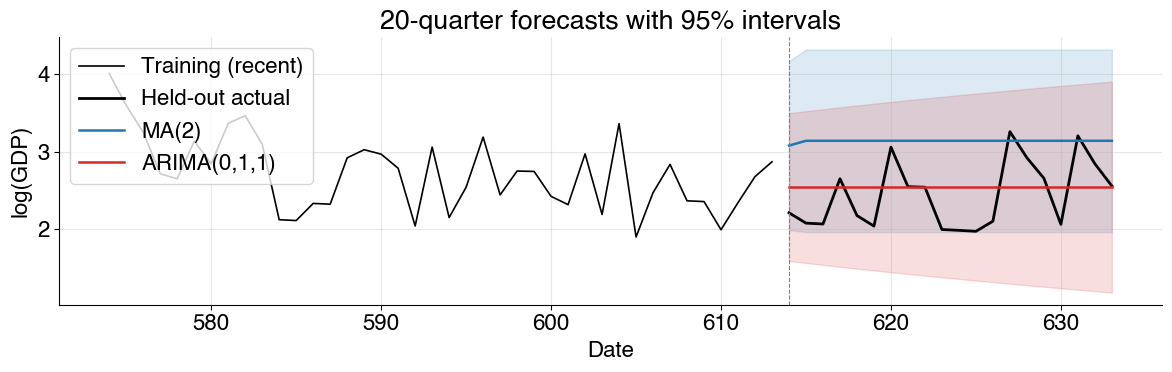

In [21]:
h = 20
y_train = ylog[:-h]
y_test = ylog[-h:]

times = np.arange(len(ylog))
times_train = times[:-h]
times_test = times[-h:]

# ---- 3. Model grid ----
specs = [
    (1, 0, 0), (2, 0, 0), (3, 0, 0), # AR
    (0, 0, 1), (0, 0, 2), (0, 0, 3), # MA
    (0, 1, 1), (0, 1, 2), (0, 1, 3), # 
    (1, 0, 1), (2, 0, 1), (3, 0, 1), # ARMA
    (1, 1, 0), (2, 1, 0), (3, 1, 0), # ARIMA
]

# ---- 4. Fit, forecast, score ----
results = []
fits = {}
for (p, d, q) in specs:
    try:
        if d == 0:
            trend = 'c'
        elif d == 1:
            trend = 'n'
        else:
            trend = 'n'
        fit = ARIMA(y_train, order=(p, d, q), trend=trend).fit()
        fcast = fit.get_forecast(steps=h)
        mean = np.asarray(fcast.predicted_mean)
        ci = np.asarray(fcast.conf_int(alpha=0.05))
        rmse = np.sqrt(np.mean((mean - y_test) ** 2))
        results.append({
            'spec': f'ARIMA({p},{d},{q})',
            'p': p, 'd': d, 'q': q,
            'n_params': p + q,
            'rmse': rmse,
        })
        fits[(p, d, q)] = (mean, ci)
    except Exception as e:
        print(f'ARIMA({p},{d},{q}) failed: {e}')

df = pd.DataFrame(results)

plt.figure()

# RMSE vs. complexity
colors = {0: 'C0', 1: 'C3', 2: 'C2'}

for d_val in sorted(df['d'].unique()):
    sub = df[df['d'] == d_val]
    plt.scatter(sub['n_params'], sub['rmse'],
               c=colors[d_val], s=80,
               label=f'd = {d_val}', edgecolor='k', linewidth=0.5)
    for _, row in sub.iterrows():
        plt.gca().annotate(row['spec'], (row['n_params'], row['rmse']),
                    xytext=(5, 5), textcoords='offset points')

plt.xlabel('# ARMA parameters (p + q)')
plt.gca().set_xticks(np.arange(1,5))
plt.ylabel(f'RMSE')
plt.title('Forecast accuracy vs. model complexity')
plt.legend(title='Differencing', loc='upper right')
plt.grid(alpha=0.3)

# Forecast

plt.figure()
context = 40 # Quarters to look back in the past (zooming in)
plt.plot(times_train[-context:], y_train[-context:],
        color='black', lw=1.2, label='Training (recent)')
plt.plot(times_test, y_test, color='black', lw=2, label='Held-out actual')

highlight = {
    (0, 0, 1): ('MA(2)', 'C0'),
    (0, 1, 1): ('ARIMA(0,1,1)', 'C3'),
    (1, 1, 1): ('ARIMA(1,1,1)', 'C2'),
}

for spec, (label, color) in highlight.items():
    if spec not in fits:
        continue
    mean, ci = fits[spec]
    plt.plot(times_test, mean, color=color, lw=1.8, label=label)
    plt.fill_between(times_test, ci[:, 0], ci[:, 1], color=color, alpha=0.15)

plt.axvline(times_test[0], color='gray', ls='--', lw=0.8)
plt.xlabel('Date')
plt.ylabel('log(GDP)')
plt.title(f'{h}-quarter forecasts with 95% intervals')
plt.legend(loc='upper left')
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

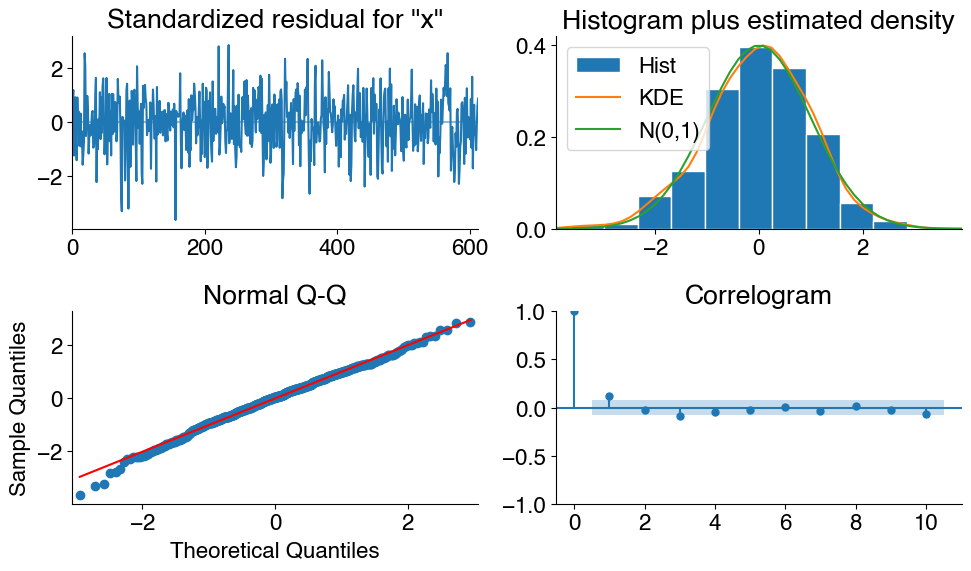

In [24]:
p=0
d=1
q=1
fit = ARIMA(y_train, order=(p, d, q), trend=trend).fit()

fig = plt.figure(figsize=(10,6))
fit.plot_diagnostics(fig=fig);
plt.tight_layout()

# Ljung-Box p-values

These diagnostics allow us to look at properties of our residuals, but there is one more statistic that is helpful to look at when choosing - the Ljung-Box-Pierce Q statistic. 

Looking at the residual ACF plot lag-by-lag (above called "correlogram") can miss a problem where every individual $\hat{\rho}_e(h)$ is just barely under the significance threshold but collectively they're too large. The Q statistic tests them jointly:

$$Q=n(n+2) \sum_{h=1}^{H} \frac{\hat{\rho}_e^2(h)}{n-h}$$

where $n$ is the number of residuals (time points estimated), $h$ is the lag index, and $H$ is the upper cutoff for lags we'll pool over.

In [25]:
acorr_ljungbox(fit.resid, lags=20, model_df=p+q)

,lb_stat,lb_pvalue
1,7.495381,NaN
2,7.574612,0.005920
3,10.540130,0.005143
4,12.713483,0.005299
5,13.069365,0.010942
6,13.299219,0.020730
7,14.303890,0.026420
8,14.305191,0.046012
9,14.370858,0.072597
10,17.126214,0.046776


,lb_stat,lb_pvalue
1,0.043490,NaN
2,1.348624,NaN
3,1.356608,0.244126
4,1.356782,0.507433
5,1.536546,0.673862
6,3.270533,0.513615
7,3.822495,0.575245
8,4.048409,0.670125
9,4.072609,0.771377
10,6.180928,0.626973


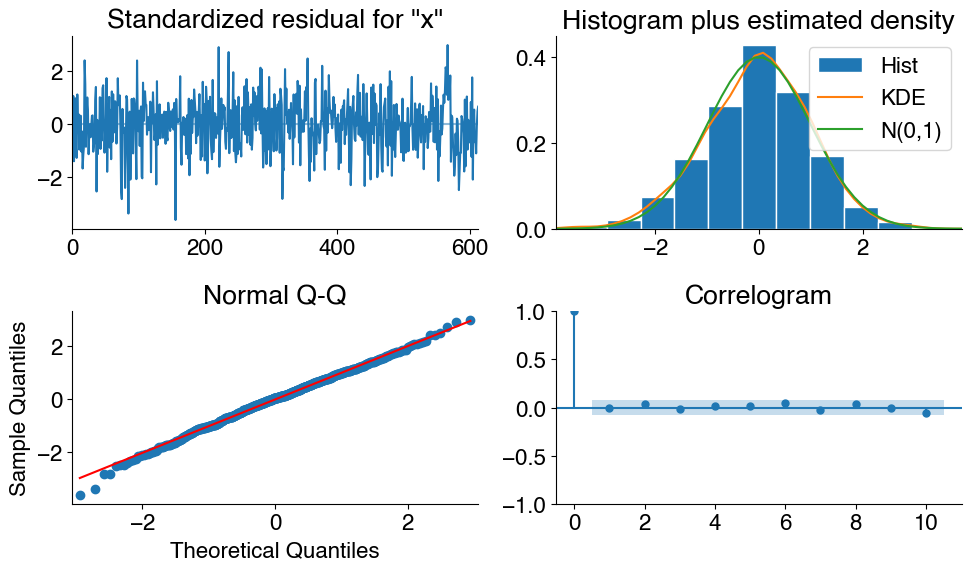

In [26]:
p=1
d=1
q=1
fit = ARIMA(y_train, order=(p, d, q), trend=trend).fit()

fig = plt.figure(figsize=(10,6))
fit.plot_diagnostics(fig=fig);
plt.tight_layout()

acorr_ljungbox(fit.resid, lags=20, model_df=p+q)

In [28]:
fit.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                  296
Model:                 ARIMA(3, 2, 1)   Log Likelihood                 901.109
Date:                Tue, 07 Apr 2026   AIC                          -1792.218
Time:                        09:48:18   BIC                          -1773.800
Sample:                             0   HQIC                         -1784.842
                                - 296                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.1414      0.053      2.688      0.007       0.038       0.244
ar.L2          0.1514      0.073      2.080      0.038       0.009       0.294
ar.L3         -0.0988      0.082     -1.210      0.226      -0.259       0.061
ma.L1         -0.9895      0.021    -47.609      0.000      -1.030      -0.949
sigma2         0.0001   4.27e-06     29.140      0.000       0.000       0.000
===================================================================================
Ljung-Box (L1) (Q):                   0.17   Jarque-Bera (JB):              5608.00
Prob(Q):                              0.68   Prob(JB):                         0.00
Heteroskedasticity (H):               1.54   Skew:                             0.01
Prob(H) (two-sided):                  0.03   Kurtosis:                        24.40
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""